# ACS 2024 Income Model — Experiment 4 Lite (three-booster tuned stacked ensemble)

A working scaffold derived from **`ML_Model_Building_Template.md`**, wired to **`acs2024v1.1_income.csv`** — the rich 18-feature ACS 2024 extract produced by `acs2024v1.1_income_extraction.ipynb`. Run top-to-bottom. This **lite** variant trains only the three deployable boosters and their tuned stacked ensemble, and saves the slim bundle the lite app ships.

**Dataset:** `acs2024v1.1_income.csv` — 1,359,710 employed working-age adults, socio-economic predictors from the 2024 ACS PUMS (1-Year).

| Column | Meaning | Kind |
|---|---|---|
| `AGEP` | Age in years | continuous |
| `WKHP` | Usual hours worked per week | continuous |
| `WKWN` | Weeks worked in past 12 months | continuous |
| `COW` | Class of worker (employment sector) | categorical |
| `SCHL` | Education level (ordinal code) | categorical |
| `MAR` | Marital status | categorical |
| `OCCP` | Occupation code | categorical |
| `INDP` | Industry code | categorical |
| `POBP` | Place of birth | categorical |
| `RELSHIPP` | Relationship to householder | categorical |
| `SEX` | Sex | categorical |
| `RAC1P` | Race group | categorical |
| `HISP` | Hispanic origin | categorical |
| `CIT` | Citizenship status | categorical |
| `NATIVITY` | Nativity (native / foreign-born) | categorical |
| `ENG` | English-speaking ability | categorical |
| `DIS` | Disability | categorical |
| `ST` | State (FIPS code) | categorical |
| **`WAGP`** | **Target — wages/salary income (scaled)** | continuous |

| Stage | Name | Key concern |
|---|---|---|
| 1 | Environment Setup | Reproducibility |
| 2 | Data Loading & Preview | Understand structure & quality |
| 3 | Data Cleaning | Missing values -> encoding -> imbalance |
| 4 | Graphical EDA | Distributions & relationships |
| 5 | Feature Set + Encoding | All raw + interaction + leak-safe target/freq encoding |
| 6 | Train / Val / Test Split | Stratified, no leakage |
| 7 | Feature Scaling | Fit on train only |
| 8 | Model Architecture | Algorithm choice & hyperparameters |
| 9 | Training | Cross-validation or epoch-based |
| 10 | Learning Curves | Diagnose over/underfitting |
| 11 | Evaluation | Training + test metrics |
| 12 | Save & Inference | Persistence & deployment |

> **Task type:** **regression** — predict `WAGP` from the remaining 18 features. The categorical columns are integer-coded ACS values (`OCCP`, `INDP`, `POBP`, `ST` are high-cardinality), which suits native-categorical gradient-boosted trees.
>
> **Models:** Stages 8-12 train the **three gradient boosters** — XGBoost, LightGBM, CatBoost — and a **tuned stacking ensemble** that blends them with a Ridge meta-learner. This is the *lite* deployment: only the learners the lite app ships. The features still follow the Experiment 4 recipe — **Mincer earnings-function terms** `AGE2` and `SCHLxAGEP` (Stage 5b) plus an `OCCP`×`INDP` *pair* target-encoding and `OCCP_te`×hours / `INDP_te`×hours interactions (Stage 6b). The three boosters each score Test R² ≈ 0.51 and their tuned stack is a faithful, lightweight stand-in for the full six-learner ensemble (the wage signal is feature-bound, so the heavy RandomForest/ExtraTrees add negligible accuracy).

## Stage 1 — Environment Setup & Library Imports

Import everything upfront, set display options so nothing is truncated, and fix a global seed for reproducibility.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
np.set_printoptions(threshold=10000)

## Stage 2 — Data Loading & Textual Preview

Load `acs2024v1.1_income.csv` and inspect it textually: shape, head/tail, schema, summary stats, and target distribution. Note any data-quality problems to fix in Stage 3.

In [2]:
# Load dataset
dataset = pd.read_csv("acs2024v1.1_income.csv", header=0, index_col=None)

TARGET_COLUMN   = "WAGP"
FEATURE_COLUMNS = [c for c in dataset.columns if c != TARGET_COLUMN]
# Continuous vs. categorical (categoricals are integer-coded ACS values).
# OCCP, INDP, POBP, ST are high-cardinality -> prefer native-categorical models.
CONTINUOUS_COLS  = ["AGEP", "WKHP", "WKWN"]
CATEGORICAL_COLS = ["COW", "SCHL", "MAR", "OCCP", "INDP", "POBP", "RELSHIPP",
                    "SEX", "RAC1P", "HISP", "CIT", "NATIVITY", "ENG", "DIS", "ST"]

print("Shape:", dataset.shape, "\n")
print(dataset.head(), "\n")
print(dataset.tail(), "\n")

Shape: (1359710, 19) 

   AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
0    24    36    52    1    21    5  5400  7980     1        20    2      1     1    1         1    0    2   1  0.021320
1    57    40    52    7    18    1  5740  7790     1        20    2      1     1    1         1    0    2   1  0.068022
2    55    45    52    7    13    1   440   770     1        21    1      1     1    1         1    0    2   1  0.079189
3    21    40    52    1    16    1  8140  8870     1        32    1      1     1    1         1    0    2   1  0.040610
4    34    40    52    2    20    5  3655  8170     1        20    2      2     1    1         1    0    2   1  0.022335 

         AGEP  WKHP  WKWN  COW  SCHL  MAR  OCCP  INDP  POBP  RELSHIPP  SEX  RAC1P  HISP  CIT  NATIVITY  ENG  DIS  ST      WAGP
1359705    59    36    52    1    22    3  3603  8191   138        20    2      1     1    5         2    0    2  56  0.04

<class 'pandas.DataFrame'>
RangeIndex: 1359710 entries, 0 to 1359709
Data columns (total 19 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   AGEP      1359710 non-null  int64  
 1   WKHP      1359710 non-null  int64  
 2   WKWN      1359710 non-null  int64  
 3   COW       1359710 non-null  int64  
 4   SCHL      1359710 non-null  int64  
 5   MAR       1359710 non-null  int64  
 6   OCCP      1359710 non-null  int64  
 7   INDP      1359710 non-null  int64  
 8   POBP      1359710 non-null  int64  
 9   RELSHIPP  1359710 non-null  int64  
 10  SEX       1359710 non-null  int64  
 11  RAC1P     1359710 non-null  int64  
 12  HISP      1359710 non-null  int64  
 13  CIT       1359710 non-null  int64  
 14  NATIVITY  1359710 non-null  int64  
 15  ENG       1359710 non-null  int64  
 16  DIS       1359710 non-null  int64  
 17  ST        1359710 non-null  int64  
 18  WAGP      1359710 non-null  float64
dtypes: float64(1), int64(18)
memory 

               AGEP          WKHP          WKWN           COW          SCHL           MAR          OCCP          INDP          POBP      RELSHIPP           SEX         RAC1P          HISP           CIT      NATIVITY           ENG           DIS            ST          WAGP
count  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06  1.359710e+06
mean   4.137099e+01  3.929257e+01  4.897903e+01  1.844407e+00  1.890821e+01  2.587045e+00  3.871180e+03  6.401180e+03  6.965008e+01  2.228875e+01  1.489646e+00  2.821533e+00  1.794312e+00  1.577574e+00  1.159276e+00  3.343007e-01  1.931193e+00  2.784002e+01  7.392101e-02
std    1.304084e+01  1.145737e+01  9.184432e+00  1.562872e+00  3.374888e+00  1.838451e+00  2.704875e+03  2.563718e+03  9.784231e+01  4.153461e+00  4.998930e-01  2.997917e+00  3.208498e

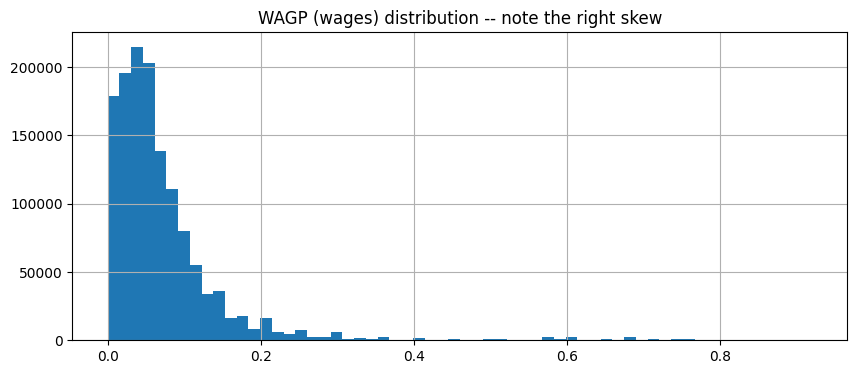

In [3]:
# Structure, dtypes, missing counts, summary stats
print(dataset.info(), "\n")
print(dataset.describe(), "\n")
print("Missing values per column:\n", dataset.isna().sum(), "\n")

# Cardinality of categorical columns (flags high-cardinality features for model choice)
print("Unique values per categorical column:")
print(dataset[CATEGORICAL_COLS].nunique().sort_values(ascending=False), "\n")

# Target distribution (regression -> describe + histogram)
print(dataset[TARGET_COLUMN].describe())
dataset[TARGET_COLUMN].hist(bins=60, figsize=(10, 4))
plt.title("WAGP (wages) distribution -- note the right skew"); plt.show()

### Stage 2 — Data-quality notes

- **Shape:** 1,359,710 rows x 19 columns (18 features + `WAGP` target).
- **No missing values:** the extraction step already filtered and sentinel-filled the data.
- **Categoricals are integer-coded:** no string encoding needed. `OCCP`, `INDP`, `POBP`, and `ST` are high-cardinality (hundreds of levels) -> favour native-categorical learners (CatBoost / XGBoost / LightGBM) over one-hot.
- **Target `WAGP` is already scaled** to roughly `[0, 0.92]` (not raw dollars) and is **right-skewed** -> `log1p` transform before training; metrics are converted back to dollars (x1e6) at evaluation.

## Stage 3 — Data Cleaning & Problem Fixing

Fix problems **before** encoding/transformation: missing values, categorical handling, and a few dataset-specific checks. For `acs2024v1.1_income.csv` the data is already clean — no nulls, integer-coded categoricals, a continuous regression target — so these steps mostly confirm the data and build the `log1p` target.

- **Missing values** — impute any NaNs (continuous via KNN, categorical via a -1 sentinel).
- **Categorical handling** — keep the native integer codes for the tree models.
- **Class imbalance** — not applicable to a continuous regression target.
- **Dataset-specific** — duplicate-row check and the `log1p(WAGP)` target transform.

In [4]:
# Impute any missing values: continuous via KNN, categorical via a -1 sentinel.
# The extractor already sentinel-filled non-applicable OCCP/INDP with -1 ("no
# occupation/industry" as its own category), so this normally finds nothing to fill.
from sklearn.impute import KNNImputer

cols_with_nulls = [c for c in dataset.columns if dataset[c].isna().any()]
if cols_with_nulls:
    cont_nulls = [c for c in cols_with_nulls if c in CONTINUOUS_COLS]
    cat_nulls  = [c for c in cols_with_nulls if c in CATEGORICAL_COLS]
    if cont_nulls:                                   # continuous -> KNN (or median)
        dataset[cont_nulls] = KNNImputer(n_neighbors=5).fit_transform(dataset[cont_nulls])
    for c in cat_nulls:                              # categorical -> dedicated sentinel
        dataset[c] = dataset[c].fillna(-1)

print("Columns with nulls:", cols_with_nulls)
print("Remaining missing values:", int(dataset.isna().sum().sum()))

Columns with nulls: []
Remaining missing values: 0


In [5]:
# Categorical handling. Columns are already integer-coded ACS values, so no string
# encoding is needed; downstream models consume the codes directly.
HIGH_CARD = ["OCCP", "INDP", "POBP", "ST"]                 # 525 / 257 / 222 / 51 levels

# CatBoost consumes these directly via cat_features; XGBoost/LightGBM via category dtype.
for c in CATEGORICAL_COLS:
    dataset[c] = dataset[c].astype(int)
print("Categoricals enforced as int. High-cardinality levels:",
      {c: int(dataset[c].nunique()) for c in HIGH_CARD})


Categoricals enforced as int. High-cardinality levels: {'OCCP': 525, 'INDP': 257, 'POBP': 222, 'ST': 51}


In [6]:
# Class imbalance handling does not apply: WAGP is a continuous regression target.
print("Regression target -- no resampling applied.")

Regression target -- no resampling applied.


In [7]:
# Dataset-specific checks.

# Duplicate rows: PUMS can legitimately repeat identical feature rows -> inspect, keep.
print("Exact duplicate rows:", int(dataset.duplicated().sum()))

# Census top-codes very high wages, compressing the right tail of WAGP (already
# scaled to ~[0, 0.92] here).

# Target transform for the right-skewed wage: build a log1p target as a separate
# series (not added as a feature column). Invert with expm1 before dollar metrics.
y_log = np.log1p(dataset[TARGET_COLUMN])
print("\nlog1p(WAGP) summary:")
print(y_log.describe())

Exact duplicate rows: 14825

log1p(WAGP) summary:
count    1.359710e+06
mean     6.874462e-02
std      6.893320e-02
min      4.060992e-06
25%      3.000288e-02
50%      5.144663e-02
75%      8.743608e-02
max      6.527583e-01
Name: WAGP, dtype: float64


## Stage 4 — Graphical Data Exploration (EDA)

Visualise distributions and relationships before engineering features. The skewed continuous histograms justify the target transform; the grouped-median bars and the focused scatter confirm the headline socio-economic signal (education, hours, sex) is present.

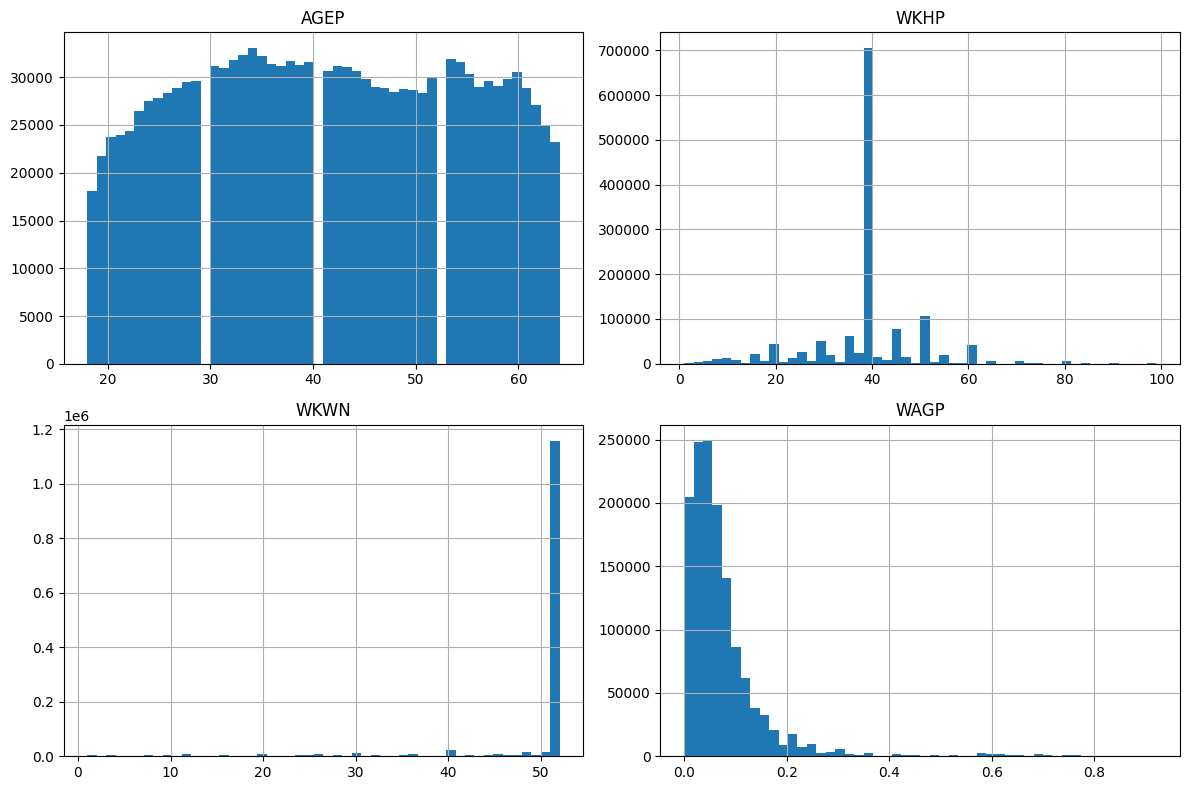

In [8]:
# Distribution of the continuous features + target. (Categorical columns are integer
# CODES, so a numeric histogram of them is not meaningful -- a few key ones are shown
# as grouped medians below instead.)
dataset[CONTINUOUS_COLS + [TARGET_COLUMN]].hist(bins=50, figsize=(12, 8))
plt.tight_layout(); plt.show()

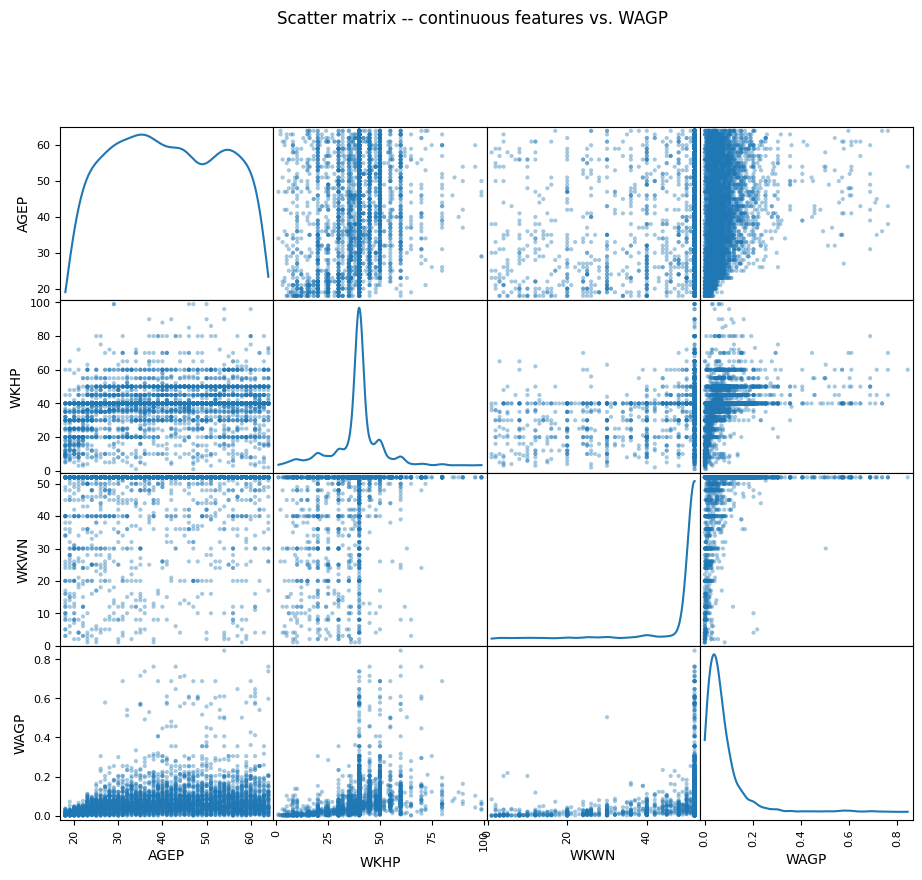

In [9]:
# Pairwise scatter matrix on the continuous features + target (sampled for speed).
from pandas.plotting import scatter_matrix

attrs = CONTINUOUS_COLS + [TARGET_COLUMN]
scatter_matrix(dataset[attrs].sample(5000, random_state=RANDOM_STATE),
               alpha=0.4, figsize=(11, 9), diagonal="kde")
plt.suptitle("Scatter matrix -- continuous features vs. WAGP", y=1.01); plt.show()

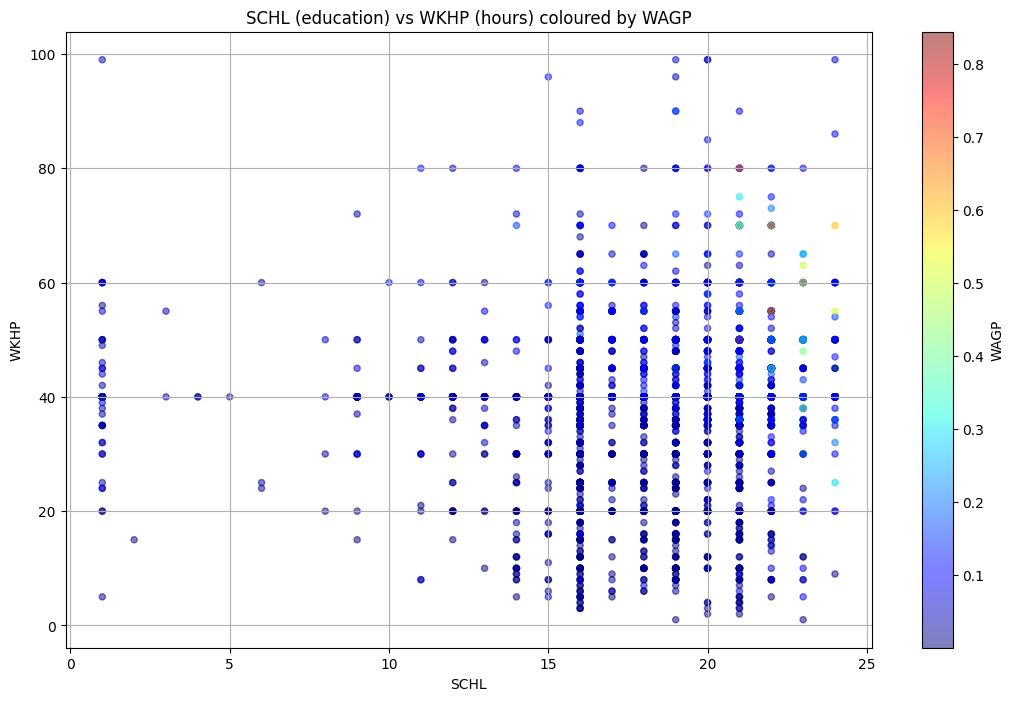

In [10]:
# Focused scatter: education vs. usual hours worked, coloured by wage.
# SCHL and WKHP are two of the strongest wage drivers, so plotting them together with
# WAGP as colour is a quick signal check: the highest wages concentrate where high
# education meets full-time hours -- pay is driven by the COMBINATION of features, not
# either axis alone. That visible interaction is the empirical motivation for the
# engineered interaction / Mincer terms (ANNUAL_HOURS, SCHLxAGEP) added in Stage 5,
# which hand the models products they cannot form on their own.
dataset.sample(5000, random_state=RANDOM_STATE).plot(
    kind="scatter", x="SCHL", y="WKHP", c=TARGET_COLUMN, cmap="jet",
    colorbar=True, grid=True, figsize=(13, 8), alpha=0.5)
plt.title("SCHL (education) vs WKHP (hours) coloured by WAGP"); plt.show()

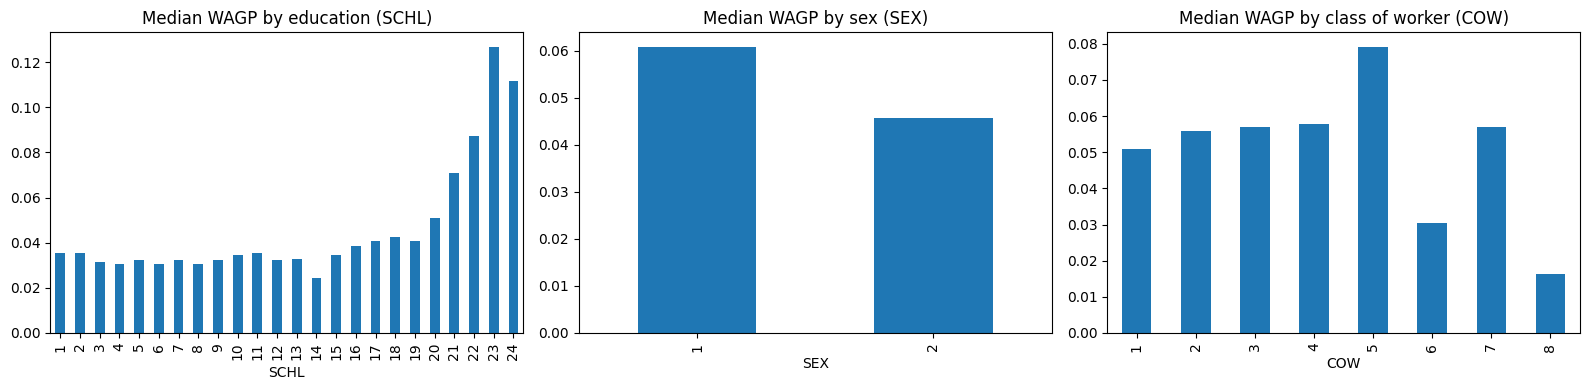

In [11]:
# Signal check: median wage by a few key categoricals (codes ordered on the x-axis).
# The categoricals are nominal integer codes, so they carry no meaning in the numeric
# scatter / correlation views -- grouping the median wage by level is the right way to
# read their signal. A large spread of medians across a feature's levels (wage rising
# with education SCHL, a gap by SEX, differences by class-of-worker COW) means the
# feature genuinely separates pay and is worth keeping/encoding. Median is used because
# the wage distribution is right-skewed, so it is more robust than the mean. This is the
# signal the trees exploit through splits and that target encoding hands to the non-
# native learners.
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
dataset.groupby("SCHL")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[0])
ax[0].set_title("Median WAGP by education (SCHL)")
dataset.groupby("SEX")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[1])
ax[1].set_title("Median WAGP by sex (SEX)")
dataset.groupby("COW")[TARGET_COLUMN].median().plot(kind="bar", ax=ax[2])
ax[2].set_title("Median WAGP by class of worker (COW)")
plt.tight_layout(); plt.show()

## Stage 5 — Feature Set

Keep **all raw features** (no Select-K-Best) and add interaction features that the models cannot reconstruct on their own, plus the leak-safe encodings built in Stage 6b:

- **5b (pre-split, leak-free):** `ANNUAL_HOURS = WKHP × WKWN`, plus two **Mincer earnings-function** terms — `AGE2 = AGEP²` (the concave age–earnings profile) and `SCHLxAGEP = SCHL × AGEP` (education × experience). These mainly help the linear models, which cannot form curvature or products themselves.
- **6b (post-split, leak-safe):** `OCCP`/`INDP`/`POBP`/`ST` target+frequency encodings, **plus** an `OCCP`×`INDP` *pair* target-encoding (job-within-sector pay) and the interactions `OCCP_te × ANNUAL_HOURS` / `INDP_te × ANNUAL_HOURS` (expected occupational/industry pay scaled by labour supply).

Features are ranked by mutual information for insight only; none are dropped.

In [12]:
# Feature identification: keep all raw features. y_sel is the log1p target; trgt_y
# keeps raw WAGP for dollar-scale reporting later.
feats_X = dataset[FEATURE_COLUMNS].copy()
trgt_y  = pd.DataFrame(dataset[[TARGET_COLUMN]])
y_sel   = y_log
print('feats_X (raw 18 features):', feats_X.shape, '| trgt_y:', trgt_y.shape)

feats_X (raw 18 features): (1359710, 18) | trgt_y: (1359710, 1)


In [13]:
# Feature generation: add the ANNUAL_HOURS interaction and two Mincer earnings-
# function terms, alongside every raw feature.
feats_X['ANNUAL_HOURS'] = feats_X['WKHP'] * feats_X['WKWN']    # hours/wk x weeks worked
feats_X['AGE2']         = feats_X['AGEP'] ** 2                 # concave age-earnings profile
feats_X['SCHLxAGEP']    = feats_X['SCHL'] * feats_X['AGEP']    # education x experience
GENERATED_COLS = ['ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP']

# Sanity check for inf / NaN introduced by the new features
check = feats_X[CONTINUOUS_COLS + GENERATED_COLS].values
print("'NaN'/'inf' cells:", int(np.isinf(check).sum() + np.isnan(check).sum()))
print('Added features:', GENERATED_COLS, '| feats_X now:', feats_X.shape)

'NaN'/'inf' cells: 0
Added features: ['ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP'] | feats_X now: (1359710, 21)


In [14]:
# Rank features by mutual information with the log target, for insight; all are kept.
from sklearn.feature_selection import mutual_info_regression

ALL_FEATURES  = list(feats_X.columns)
discrete_mask = [c in CATEGORICAL_COLS for c in ALL_FEATURES]

samp = feats_X.sample(min(20000, len(feats_X)), random_state=RANDOM_STATE)
mi_scores = pd.Series(
    mutual_info_regression(samp, y_sel.loc[samp.index],
                           discrete_features=discrete_mask, random_state=RANDOM_STATE),
    index=ALL_FEATURES).sort_values(ascending=False)
selected = ALL_FEATURES
print('Mutual information with log(WAGP):')
print(mi_scores.round(4))
print('Keeping all', len(selected), 'base features; encodings and interactions are added next.')

Mutual information with log(WAGP):
OCCP            0.3424
ANNUAL_HOURS    0.3085
WKHP            0.2393
INDP            0.1703
SCHLxAGEP       0.1649
WKWN            0.1248
SCHL            0.1235
AGE2            0.1172
AGEP            0.1146
RELSHIPP        0.0934
MAR             0.0562
ST              0.0474
POBP            0.0274
COW             0.0239
SEX             0.0214
RAC1P           0.0176
HISP            0.0146
ENG             0.0106
CIT             0.0035
DIS             0.0021
NATIVITY        0.0000
dtype: float64
Keeping all 21 base features; encodings and interactions are added next.


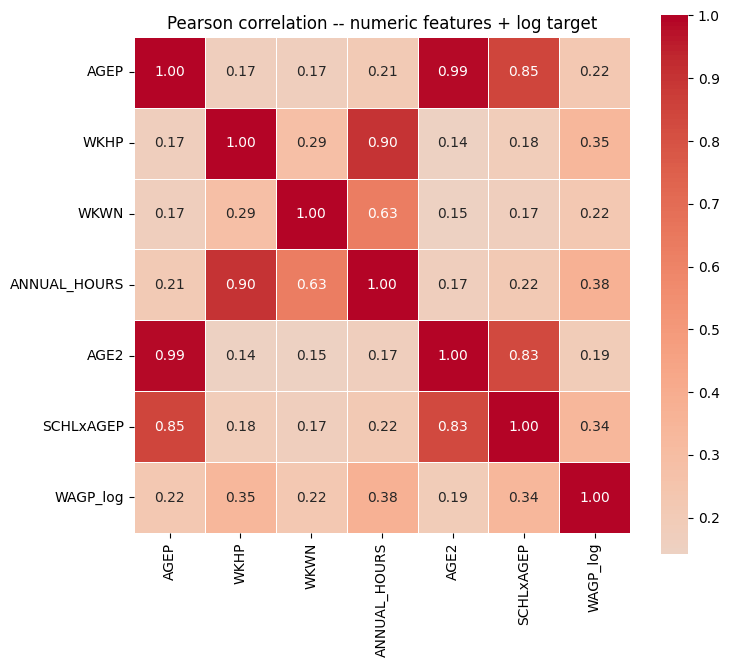

In [15]:
# Multicollinearity check: Pearson correlation on the numeric features + log target.
numeric_cols = CONTINUOUS_COLS + ['ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP']
corr = pd.concat([feats_X[numeric_cols], y_log.rename('WAGP_log')], axis=1).corr('pearson')

plt.figure(figsize=(8, 7))
sbn.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Pearson correlation -- numeric features + log target'); plt.show()

In [16]:
# Finalise the base feature set: all raw features plus the generated interaction
# terms (ANNUAL_HOURS, AGE2, SCHLxAGEP). Leak-safe encodings are appended next.
useful_feats_X = feats_X[selected].copy()
print('Base feature set:', list(useful_feats_X.columns))
print('useful_feats_X:', useful_feats_X.shape)

Base feature set: ['AGEP', 'WKHP', 'WKWN', 'COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST', 'ANNUAL_HOURS', 'AGE2', 'SCHLxAGEP']
useful_feats_X: (1359710, 21)


## Stage 6 — Train / Validation / Test Split

Regression target -> a plain shuffled `train_test_split` (an optional `qcut`-bin stratification is shown to balance income *ranges*). A validation slice is carved from train for early stopping. Targets are `log1p(WAGP)`; the `*_raw` series recover the (scaled) WAGP axis via `expm1`, then Stage 11 multiplies by 1e6 for dollars.

In [17]:
from sklearn.model_selection import train_test_split

X = useful_feats_X
y = y_sel                                   # = y_log, index-aligned with X

# Categorical subset -> native categorical handling in the tree models.
CAT_FEATURES = [c for c in X.columns if c in CATEGORICAL_COLS]
print("Categorical features carried into the models:", CAT_FEATURES)

# Primary 80/20 train-test split (shuffled).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Carve a validation slice out of train (early stopping).
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

# Raw-axis targets aligned to each split (expm1 inverts the log1p), for dollar eval.
y_train_raw = np.expm1(y_train)
y_val_raw   = np.expm1(y_val)
y_test_raw  = np.expm1(y_test)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)

Categorical features carried into the models: ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']


X_train: (870214, 21) | X_val: (217554, 21) | X_test: (271942, 21)


## Stage 6b — Leak-safe encoding & interactions

All fit on the **training split only**, then mapped onto val/test (unseen levels fall back to the global mean / 0):

- **Target encoding** — smoothed mean `log1p(WAGP)` per level of `OCCP`/`INDP`/`POBP`/`ST`; train rows use **5-fold out-of-fold** means, val/test use full-train means.
- **Frequency encoding** — each level's share of training rows.
- **`OCCP`×`INDP` pair target-encoding** — smoothed mean log-wage for the *(occupation, industry)* pair, i.e. "what does this job pay *in this sector*"; heavier smoothing (`PAIR_SMOOTH`) tames sparse pairs.
- **Encoded × hours interactions** — `OCCP_te × ANNUAL_HOURS` and `INDP_te × ANNUAL_HOURS`: expected occupational / industry pay scaled by labour supply. Built from the leak-safe `_te` columns, so they stay leak-safe.

These numeric columns are consumed by the trees (and the stack); the linear models keep their one-hot pipeline.

In [18]:
# Leak-safe target and frequency encodings (everything fit on the TRAIN split only).
from sklearn.model_selection import KFold

HIGH_CARD_TE = ['OCCP', 'INDP', 'POBP', 'ST']
GLOBAL_MEAN  = float(y_train.mean())
SMOOTH       = 20.0       # per-level shrink toward the global mean
PAIR_SMOOTH  = 50.0       # heavier shrink for the sparse OCCP x INDP pair

# Transient OCCP x INDP pair key on every split (encoded below, never kept as a feature).
for frame in (X_train, X_val, X_test):
    frame['_OCCP_INDP'] = frame['OCCP'].astype('int64') * 100000 + frame['INDP'].astype('int64')

def _smoothed(xc, yc, col, smooth):
    g = yc.groupby(xc[col]); m = g.mean(); n = g.count()
    return (m * n + GLOBAL_MEAN * smooth) / (n + smooth)

# columns to target-encode -> (source col, smoothing, output name)
TE_SPEC = [(c, SMOOTH, c + '_te') for c in HIGH_CARD_TE] + [('_OCCP_INDP', PAIR_SMOOTH, 'OCCPINDP_te')]

# 1) OUT-OF-FOLD target encoding on the training rows (no row sees its own target)
for _src, _s, out in TE_SPEC:
    X_train[out] = GLOBAL_MEAN
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for tr, va in kf.split(X_train):
    va_idx = X_train.index[va]
    for src, smooth, out in TE_SPEC:
        fmap = _smoothed(X_train.iloc[tr], y_train.iloc[tr], src, smooth)
        X_train.loc[va_idx, out] = X_train.loc[va_idx, src].map(fmap).fillna(GLOBAL_MEAN)

# 2) FULL-train maps -> val/test target encoding; frequency encoding for the single codes
full_maps = {src: _smoothed(X_train, y_train, src, smooth) for src, smooth, _o in TE_SPEC}
freq_maps = {c: X_train[c].value_counts(normalize=True) for c in HIGH_CARD_TE}
ENC_COLS  = []
for src, _smooth, out in TE_SPEC:
    X_val[out]  = X_val[src].map(full_maps[src]).fillna(GLOBAL_MEAN)
    X_test[out] = X_test[src].map(full_maps[src]).fillna(GLOBAL_MEAN)
    ENC_COLS.append(out)
for c in HIGH_CARD_TE:
    for frame in (X_train, X_val, X_test):
        frame[c + '_freq'] = frame[c].map(freq_maps[c]).fillna(0.0)
    ENC_COLS.append(c + '_freq')

# 3) Interactions: expected occupation/industry pay (target-enc) x labour supply (annual hours)
for frame in (X_train, X_val, X_test):
    frame['OCCPte_x_HOURS'] = frame['OCCP_te'] * frame['ANNUAL_HOURS']
    frame['INDPte_x_HOURS'] = frame['INDP_te'] * frame['ANNUAL_HOURS']
ENC_COLS += ['OCCPte_x_HOURS', 'INDPte_x_HOURS']

# Drop the transient pair key; align column order across splits (CatBoost matches by position).
for frame in (X_train, X_val, X_test):
    frame.drop(columns='_OCCP_INDP', inplace=True)
X_val  = X_val[X_train.columns]
X_test = X_test[X_train.columns]

print('Added leak-safe encodings + interactions:', ENC_COLS)
print('X_train:', X_train.shape, '| X_val:', X_val.shape, '| X_test:', X_test.shape)

Added leak-safe encodings + interactions: ['OCCP_te', 'INDP_te', 'POBP_te', 'ST_te', 'OCCPINDP_te', 'OCCP_freq', 'INDP_freq', 'POBP_freq', 'ST_freq', 'OCCPte_x_HOURS', 'INDPte_x_HOURS']
X_train: (870214, 32) | X_val: (217554, 32) | X_test: (271942, 32)


## Stage 7 — Feature Scaling / Normalisation

**Primary (tree) path: no scaling.** Gradient-boosted trees are scale-invariant, the target is already `log1p`-transformed, and scaling would corrupt the integer category codes. The commented **DL / linear branch** shows the leakage-safe pattern: fit on **train only**, transform **numeric features only**.

In [19]:
# Tree models are scale-invariant and the target is already log1p-transformed, so no
# feature scaling is applied; scaling the integer category codes would also corrupt them.
# The linear models standardise their own numeric columns inside their pipeline.
print("No scaling applied: gradient-boosted and bagged trees are scale-invariant.")

No scaling applied: gradient-boosted and bagged trees are scale-invariant.


## Stage 8 — Model Selection, Architecture & Compilation

Three gradient-boosted regressors are configured — the only learners the **lite** deployment ships — all on the same feature set and the same `log1p(WAGP)` target:

**Boosted trees — XGBoost / LightGBM / CatBoost.** Matched hyperparameters (`~2000` trees, `lr=0.05`, `max_depth=8`, L2, early stopping) so differences reflect the *algorithm*. All three ingest the categoricals **natively**, including high-cardinality `OCCP`/`INDP`/`ST`:
- **CatBoost** — `cat_features` (ordered boosting). **XGBoost** — `enable_categorical=True`. **LightGBM** — `categorical_feature=` (both need pandas `category` dtype).

**Tuned stacking ensemble — blend of the three boosters.** A `StackedGBM` holdout-blender: the three fitted boosters predict on the held-out validation split, and a **Ridge** meta-learner learns how to weight them (leak-safe — the boosters fit on `X_train`, the meta fits on `X_val`, everything is finally scored on `X_test`). The Ridge regularisation gives the *tuned* weights and stabilises them against the strong correlation between the three booster predictions. This three-model stack is the model the lite app ships — a faithful, lightweight stand-in for the full six-learner stack, since the wage signal is feature-bound and the heavy RandomForest/ExtraTrees add negligible accuracy.

In [20]:
from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge, LinearRegression

cat_model = CatBoostRegressor(
    iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=10,
    loss_function="RMSE", eval_metric="RMSE", random_state=RANDOM_STATE,
    early_stopping_rounds=100, verbose=400)

xgb_model = XGBRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, subsample=0.8,
    colsample_bytree=0.8, reg_lambda=10, tree_method="hist",
    enable_categorical=True, early_stopping_rounds=100,
    random_state=RANDOM_STATE, verbosity=0)

lgb_model = LGBMRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=8, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=10,
    random_state=RANDOM_STATE, verbose=-1)

print("Configured CatBoost, XGBoost, LightGBM.")
print("Categorical features:", CAT_FEATURES)

# --- Tuned stacking ensemble: holdout blend of the three fitted boosters -------
# The already-fitted boosters predict on the held-out validation split, and a Ridge
# meta-learner learns how to weight them. Leakage-safe -- the boosters train on
# X_train, the meta trains on X_val, and everything is finally scored on X_test.
class StackedGBM:
    """Blend fitted base-model predictions with a linear meta-learner.

    predict() accepts the plain integer frame and rebuilds the category-dtype copy that
    XGBoost/LightGBM need, casting with the training categories so the integer->code
    mapping stays consistent (unseen levels become NaN = missing, handled natively)."""
    def __init__(self, base_models, cat_dtypes, meta=None):
        self.base_models = base_models      # list of (name, fitted_model, needs_category)
        self.cat_dtypes  = cat_dtypes       # {col: training CategoricalDtype}
        self.meta = meta if meta is not None else LinearRegression()

    def _stack(self, X):
        Xc = X.copy()
        for c, dt in self.cat_dtypes.items():
            Xc[c] = Xc[c].astype(dt)        # cast with the train category set
        preds = [m.predict(Xc if need_cat else X)
                 for _, m, need_cat in self.base_models]
        return np.column_stack(preds)

    def fit(self, X_blend, y_blend):
        self.meta.fit(self._stack(X_blend), y_blend)
        return self

    def predict(self, X):
        return self.meta.predict(self._stack(X))

print("Defined StackedGBM blender (three-booster, Ridge meta).")

Configured CatBoost, XGBoost, LightGBM.
Categorical features: ['COW', 'SCHL', 'MAR', 'OCCP', 'INDP', 'POBP', 'RELSHIPP', 'SEX', 'RAC1P', 'HISP', 'CIT', 'NATIVITY', 'ENG', 'DIS', 'ST']
Defined StackedGBM blender (three-booster, Ridge meta).


## Stage 9 — Training

The three **boosters** train on the `log1p` target with early stopping against our validation split — CatBoost via `Pool`, XGBoost/LightGBM on **`category`-dtype copies** (built once below, with val/test cast to the *training* categories so the codes stay consistent). The **`StackedGBM`** blender then fits its Ridge meta-learner on the three boosters' validation-set predictions. The `MODELS` dict is assembled in benchmark order (three boosters, then the tuned stack) and records the frame each model predicts on.

In [21]:
import time, lightgbm as lgb

# Category-dtype copies for XGBoost / LightGBM. Build the TRAIN frame first to fix the
# category set, then cast val/test to the SAME categories so the integer->code mapping is
# consistent across splits (levels unseen in train become NaN = missing, handled natively).
def as_category(df, ref=None):
    out = df.copy()
    for c in CAT_FEATURES:
        out[c] = out[c].astype("category") if ref is None else out[c].astype(ref[c].dtype)
    return out
X_train_cat = as_category(X_train)
X_val_cat   = as_category(X_val,  ref=X_train_cat)
X_test_cat  = as_category(X_test, ref=X_train_cat)

# --- CatBoost (native Pool) ---
train_pool = Pool(X_train, y_train, cat_features=CAT_FEATURES)
val_pool   = Pool(X_val,   y_val,   cat_features=CAT_FEATURES)
t0 = time.time(); cat_model.fit(train_pool, eval_set=val_pool)
print(f"{'CatBoost':20s} trained {time.time()-t0:6.1f}s | best_iter {cat_model.get_best_iteration()}")

# --- XGBoost ---
t0 = time.time(); xgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], verbose=False)
print(f"{'XGBoost':20s} trained {time.time()-t0:6.1f}s | best_iter {xgb_model.best_iteration}")

# --- LightGBM ---
t0 = time.time()
lgb_model.fit(X_train_cat, y_train, eval_set=[(X_val_cat, y_val)], eval_metric="rmse",
              categorical_feature=CAT_FEATURES,
              callbacks=[lgb.early_stopping(100, verbose=False)])
print(f"{'LightGBM':20s} trained {time.time()-t0:6.1f}s | best_iter {lgb_model.best_iteration_}")

# --- Tuned stacking ensemble: blend the three fitted boosters on the held-out
# validation split, with a regularised Ridge meta-learner. ---
cat_dtypes  = {c: X_train_cat[c].dtype for c in CAT_FEATURES}
stack_model = StackedGBM(
    base_models=[("XGBoost", xgb_model, True),
                 ("LightGBM", lgb_model, True),
                 ("CatBoost", cat_model, False)],
    cat_dtypes=cat_dtypes, meta=Ridge(alpha=1.0))
t0 = time.time(); stack_model.fit(X_val, y_val)   # meta learns weights on out-of-base-sample preds
w = stack_model.meta.coef_
print(f"{'Stacking(GBMs)':20s} trained {time.time()-t0:6.1f}s | meta weights " +
      ", ".join(f"{n}={wi:+.2f}" for (n, _m, _c), wi in zip(stack_model.base_models, w)))

# Benchmark order: three boosters -> tuned stack (capstone). Each entry maps a model
# to the frames it predicts on during evaluation.
MODELS = {
    "XGBoost":  (xgb_model,    X_train_cat, X_test_cat),
    "LightGBM": (lgb_model,    X_train_cat, X_test_cat),
    "CatBoost": (cat_model,    X_train,     X_test),
    "Stacking(GBMs)":       (stack_model, X_train, X_test),
}

0:	learn: 0.0673776	test: 0.0675839	best: 0.0675839 (0)	total: 428ms	remaining: 14m 15s


400:	learn: 0.0464141	test: 0.0470823	best: 0.0470823 (400)	total: 1m 45s	remaining: 7m 2s


800:	learn: 0.0458517	test: 0.0468317	best: 0.0468317 (800)	total: 3m 32s	remaining: 5m 17s


1200:	learn: 0.0454280	test: 0.0467085	best: 0.0467085 (1200)	total: 5m 25s	remaining: 3m 36s


1600:	learn: 0.0451322	test: 0.0466471	best: 0.0466469 (1592)	total: 7m 18s	remaining: 1m 49s


1999:	learn: 0.0448444	test: 0.0465985	best: 0.0465984 (1995)	total: 9m 11s	remaining: 0us

bestTest = 0.0465983682
bestIteration = 1995

Shrink model to first 1996 iterations.


CatBoost             trained  552.6s | best_iter 1995


XGBoost              trained   14.1s | best_iter 338


LightGBM             trained    7.8s | best_iter 866


Stacking(GBMs)       trained    2.1s | meta weights XGBoost=+0.33, LightGBM=+0.31, CatBoost=+0.37


## Stage 10 — Learning Curve Visualisation

Left: CatBoost **train vs. validation** RMSE (the over/underfit diagnosis — a widening gap signals overfitting). Right: **validation RMSE for the three boosters** overlaid as the ensemble grows. All three add trees sequentially, so their error falls then flattens at the early-stopping point (a log x-axis keeps the ~2000-iteration boosters legible). All curves are on the `log1p` target axis.

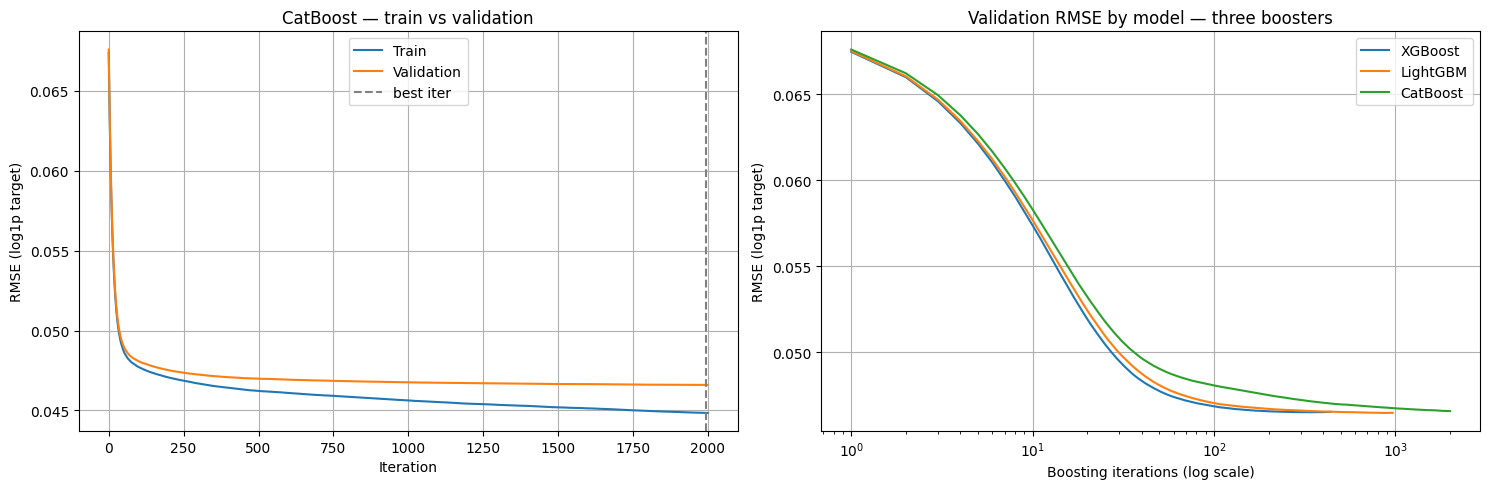

In [22]:
# Validation-RMSE learning curves for the THREE boosters, plotted as the ensemble grows.
# Each booster adds trees SEQUENTIALLY -- every new tree corrects the previous ones -- so
# its validation error falls and then flattens at the early-stopping point. A log x-axis
# keeps the ~2000-iteration boosters legible. The boosters record their per-iteration
# validation RMSE during training (free).
ev_cat = cat_model.get_evals_result()
ev_xgb = xgb_model.evals_result()
ev_lgb = lgb_model.evals_result_

curves = {
    "XGBoost":  ev_xgb["validation_0"]["rmse"],
    "LightGBM": ev_lgb["valid_0"]["rmse"],
    "CatBoost": ev_cat["validation"]["RMSE"],
}

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Left: CatBoost train vs validation (over/underfit diagnostic -- a widening gap = overfit).
ax[0].plot(ev_cat["learn"]["RMSE"], label="Train")
ax[0].plot(ev_cat["validation"]["RMSE"], label="Validation")
ax[0].axvline(cat_model.get_best_iteration(), ls="--", c="grey", label="best iter")
ax[0].set_title("CatBoost — train vs validation")
ax[0].set_xlabel("Iteration"); ax[0].set_ylabel("RMSE (log1p target)")
ax[0].legend(); ax[0].grid()

# Right: validation RMSE for the three boosters (log x: boosting iterations).
for name, curve in curves.items():
    ax[1].plot(np.arange(1, len(curve) + 1), curve, label=name)
ax[1].set_xscale("log")
ax[1].set_title("Validation RMSE by model — three boosters")
ax[1].set_xlabel("Boosting iterations (log scale)")
ax[1].set_ylabel("RMSE (log1p target)")
ax[1].legend(); ax[1].grid()

plt.tight_layout(); plt.show()

## Stage 11 — Evaluation on Training & Test Sets

Score every model on **both** train and test so the train-vs-test gap is visible. Predictions are made on the `log1p` axis, inverted with `expm1`, then multiplied by `WAGP_TO_DOLLARS = 1e6` to report **MAE / RMSE in dollars** (the extractor stored `WAGP` as adjusted dollars / 1e6). `R²` / Explained Variance are scale-free. The printed rows match the Experiment-Log format; `results_df` collects them.

In [23]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             explained_variance_score, r2_score)

WAGP_TO_DOLLARS = 1_000_000
MODS = "all-raw features + Mincer terms + OCCPxINDP pair-enc + te*hours + 3-booster stack"

rows = []
print("| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |")
print("|---|---|---|---|---|---|---|---|")
for name, (m, X_tr, X_te) in MODELS.items():           # MODELS is in benchmark order
    p_tr = np.expm1(m.predict(X_tr)) * WAGP_TO_DOLLARS
    p_te = np.expm1(m.predict(X_te)) * WAGP_TO_DOLLARS
    yt_tr = y_train_raw.values * WAGP_TO_DOLLARS
    yt_te = y_test_raw.values  * WAGP_TO_DOLLARS
    row = {
        "Algorithm": name, "Modifications": MODS,
        "Train MAE":  mean_absolute_error(yt_tr, p_tr),
        "Train RMSE": mean_squared_error(yt_tr, p_tr) ** 0.5,
        "Train R2":   r2_score(yt_tr, p_tr),
        "Test MAE":   mean_absolute_error(yt_te, p_te),
        "Test RMSE":  mean_squared_error(yt_te, p_te) ** 0.5,
        "Test R2":    r2_score(yt_te, p_te),
    }
    rows.append(row)
    print(f"| {name} | {MODS} | {row['Train MAE']:,.2f} | {row['Train RMSE']:,.2f} | "
          f"{row['Train R2']:.2f} | {row['Test MAE']:,.2f} | {row['Test RMSE']:,.2f} | {row['Test R2']:.2f} |")

# Keep rows in benchmark order; the best model is selected by Test R2 via idxmax.
results_df = pd.DataFrame(rows)
results_df

| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|---|---|---|---|---|---|---|---|


| XGBoost | all-raw features + Mincer terms + OCCPxINDP pair-enc + te*hours + 3-booster stack | 24,460.61 | 50,380.08 | 0.64 | 27,874.59 | 59,026.89 | 0.51 |


| LightGBM | all-raw features + Mincer terms + OCCPxINDP pair-enc + te*hours + 3-booster stack | 25,652.69 | 52,535.17 | 0.61 | 27,899.08 | 58,844.81 | 0.51 |


| CatBoost | all-raw features + Mincer terms + OCCPxINDP pair-enc + te*hours + 3-booster stack | 27,053.88 | 56,762.65 | 0.54 | 27,941.71 | 59,047.91 | 0.51 |


| Stacking(GBMs) | all-raw features + Mincer terms + OCCPxINDP pair-enc + te*hours + 3-booster stack | 25,514.45 | 52,950.71 | 0.60 | 27,657.24 | 58,665.22 | 0.51 |


,Algorithm,Modifications,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,XGBoost,all-raw features + Mincer terms + OCCPxINDP pa...,24460.614331,50380.077657,0.637488,27874.585556,59026.892900,0.507835
1,LightGBM,all-raw features + Mincer terms + OCCPxINDP pa...,25652.687700,52535.168184,0.605811,27899.084740,58844.811552,0.510867
2,CatBoost,all-raw features + Mincer terms + OCCPxINDP pa...,27053.876169,56762.651392,0.539818,27941.714595,59047.907395,0.507485
3,Stacking(GBMs),all-raw features + Mincer terms + OCCPxINDP pa...,25514.450416,52950.707767,0.599550,27657.236928,58665.221754,0.513848


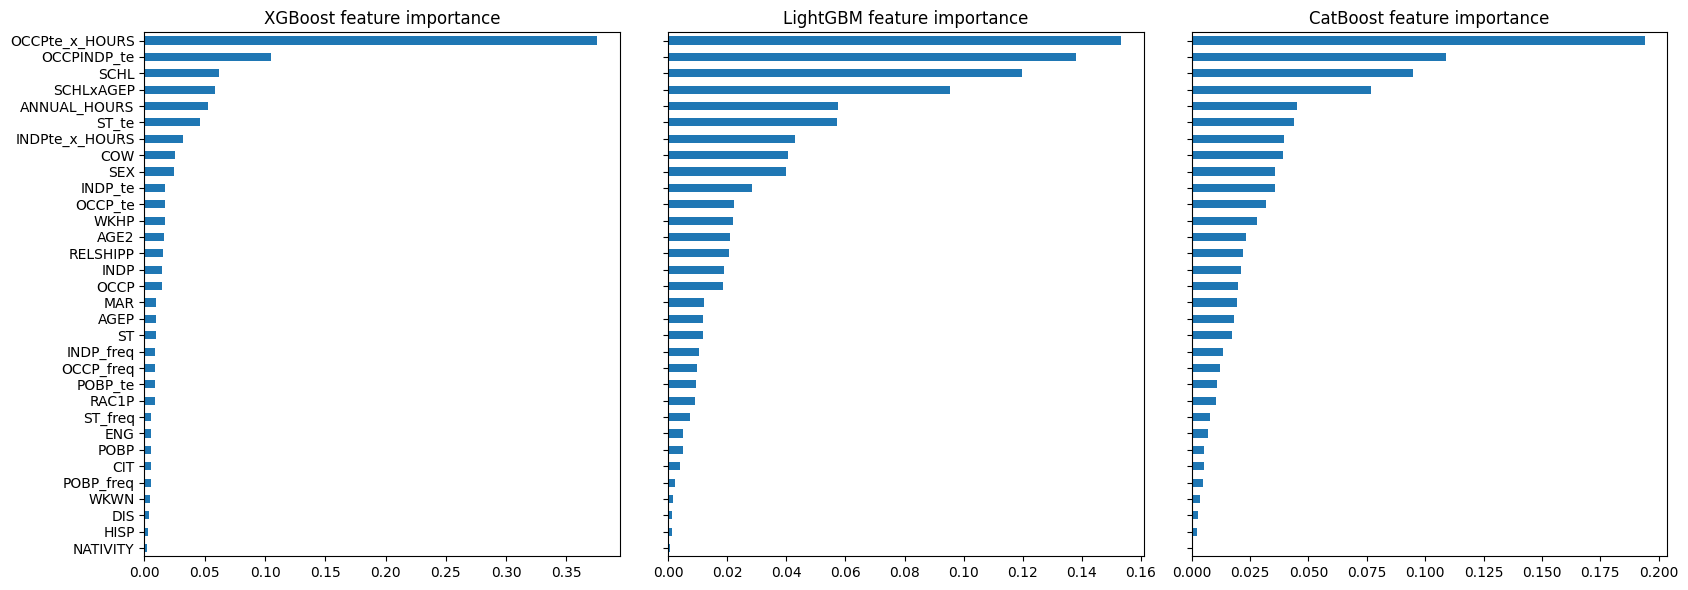

In [24]:
# Feature importance per tree model (normalised to sum=1 so the three are comparable).
# The linear baselines are excluded: their "importance" lives in hundreds of post-one-
# hot coefficients rather than the raw feature columns, so they aren't directly comparable.
TREE_MODELS = {k: MODELS[k] for k in ("XGBoost", "LightGBM", "CatBoost")}
fig, ax = plt.subplots(1, 3, figsize=(17, 6), sharey=True)
for a, (name, (m, _, _)) in zip(ax, TREE_MODELS.items()):
    imp = pd.Series(m.get_feature_importance() if name == "CatBoost"
                    else m.feature_importances_, index=list(X_train.columns))
    (imp / imp.sum()).sort_values().plot(kind="barh", ax=a)
    a.set_title(f"{name} feature importance")
plt.tight_layout(); plt.show()

## Stage 12 — Model Saving & Inference

Persist the **lite deployment bundle**: the three fitted boosters (XGBoost, LightGBM, CatBoost), the **tuned stacking meta-learner** (the fitted Ridge plus the booster order, saved *class-free* so the bundle unpickles without any custom class in scope), and the shared preprocessing metadata (feature list, categorical columns + their training category sets, target transform, dollar scale, and all encoding maps) so inference reproduces the exact pipeline. Saved as `acs2024v1.1_income_models_exp4lite.pkl`. The sanity-check reloads the bundle and reconstructs the tuned stacked prediction class-free from the boosters + Ridge meta.

In [25]:
import joblib
from pandas.api.types import CategoricalDtype

best_name = results_df.loc[results_df["Test R2"].idxmax(), "Algorithm"]

# Training category sets so the lite app can rebuild the pandas CategoricalDtype that
# XGBoost/LightGBM need at predict time.
cat_categories = {c: [int(x) for x in X_train_cat[c].cat.categories.tolist()]
                  for c in CAT_FEATURES}

# The tuned stack is saved CLASS-FREE: the fitted Ridge meta + the booster order it was
# trained on. A stacked prediction is meta.predict(column_stack([booster preds in
# blend_order])) -- no custom class needed to load or use the bundle.
blend_order = [n for (n, _m, _c) in stack_model.base_models]   # ["XGBoost","LightGBM","CatBoost"]

bundle = {
    "models": {n: MODELS[n][0] for n in ("XGBoost", "LightGBM", "CatBoost")},
    "best_model": best_name,
    "blend_order": blend_order,
    "stack_meta": stack_model.meta,        # fitted Ridge meta-learner (tuned weights)
    "stack_weights": dict(zip(blend_order, [float(x) for x in stack_model.meta.coef_])),
    "stack_intercept": float(stack_model.meta.intercept_),
    "features": list(X_train.columns),
    "cat_features": CAT_FEATURES,
    "cat_categories": cat_categories,
    "target": TARGET_COLUMN,
    "target_transform": "log1p / expm1",
    "wagp_to_dollars": WAGP_TO_DOLLARS,
    "generated_features": GENERATED_COLS,
    "encoding_cols": ENC_COLS,
    "target_enc_maps": full_maps,          # incl. the OCCPxINDP pair map
    "freq_maps": freq_maps,
    "global_mean": GLOBAL_MEAN, "smooth": SMOOTH, "pair_smooth": PAIR_SMOOTH,
    "survey_year": "2024",
    "results": results_df,
    "note": "lite: three-booster (XGB+LGBM+CatBoost) tuned stacked ensemble (Ridge meta) from exp4",
}
joblib.dump(bundle, "acs2024v1.1_income_models_exp4lite.pkl", compress=3)
print("Saved acs2024v1.1_income_models_exp4lite.pkl | best model:", best_name)

# Reload and predict on a sample, reconstructing the tuned stack CLASS-FREE.
loaded = joblib.load("acs2024v1.1_income_models_exp4lite.pkl")
scale  = loaded["wagp_to_dollars"]
cdt    = {c: CategoricalDtype(categories=cats) for c, cats in loaded["cat_categories"].items()}

def lite_stack_predict(X_int, loaded, cdt):
    """Tuned stacked-ensemble prediction from the saved class-free bundle."""
    Xc = X_int.copy()
    for c, dt in cdt.items():
        Xc[c] = Xc[c].astype(dt)
    base = {"XGBoost":  loaded["models"]["XGBoost"].predict(Xc),
            "LightGBM": loaded["models"]["LightGBM"].predict(Xc),
            "CatBoost": loaded["models"]["CatBoost"].predict(X_int)}
    stacked = np.column_stack([base[n] for n in loaded["blend_order"]])
    return loaded["stack_meta"].predict(stacked)

sample_pred = np.expm1(lite_stack_predict(X_test[:5], loaded, cdt)) * scale
print("\nGround-truth WAGP:", [f"${v:,.0f}" for v in y_test_raw.values[:5] * scale])
print("Predicted   WAGP:", [f"${v:,.0f}" for v in sample_pred])
print("Tuned stack weights:", loaded["stack_weights"], "| intercept", round(loaded["stack_intercept"], 4))

Saved acs2024v1.1_income_models_exp4lite.pkl | best model: Stacking(GBMs)



Ground-truth WAGP: ['$17,767', '$44,671', '$208,126', '$30,457', '$50,762']
Predicted   WAGP: ['$25,770', '$84,314', '$204,203', '$48,409', '$57,566']
Tuned stack weights: {'XGBoost': 0.3298858776258534, 'LightGBM': 0.3140538552431717, 'CatBoost': 0.3655934621321042} | intercept -0.0007


---
## Experiment Log — EXP4 Lite (three-booster tuned stacked ensemble)

The three gradient boosters (XGBoost, LightGBM, CatBoost) on the all-raw feature set plus the exp4 additions: `ANNUAL_HOURS` and the Mincer terms `AGE2`/`SCHLxAGEP` (Stage 5b); leak-safe target+frequency encodings of `OCCP`/`INDP`/`POBP`/`ST`, the `OCCP`×`INDP` pair target-encoding, and the `OCCP_te`/`INDP_te` × hours interactions (Stage 6b); and a **tuned stacking blend over the three boosters** with a Ridge meta-learner (Stage 9). 32 feature columns total. Trained on `log1p(WAGP)`; MAE/RMSE reported in dollars (×1e6), R² scale-free. Best Test R² in **bold**.

| Algorithm | Modifications | Train MAE | Train RMSE | Train R2 | Test MAE | Test RMSE | Test R2 |
|---|---|---|---|---|---|---|---|
| XGBoost | exp4lite: +Mincer +pair-enc +te×hours +3-booster stack | 24,460.61 | 50,380.08 | 0.64 | 27,874.59 | 59,026.89 | 0.51 |
| LightGBM | exp4lite: +Mincer +pair-enc +te×hours +3-booster stack | 25,652.69 | 52,535.17 | 0.61 | 27,899.08 | 58,844.81 | 0.51 |
| CatBoost | exp4lite: +Mincer +pair-enc +te×hours +3-booster stack | 27,053.88 | 56,762.65 | 0.54 | 27,941.71 | 59,047.91 | 0.51 |
| **Stacking(GBMs)** | exp4lite: +Mincer +pair-enc +te×hours +3-booster stack | 25,514.45 | 52,950.71 | 0.60 | **27,657.24** | **58,665.22** | **0.51** |

**Best: Stacking(GBMs) — Test R² 0.5138, MAE $27,657.** Tuned Ridge-meta stack weights: XGBoost +0.330, LightGBM +0.314, CatBoost +0.366 (intercept -0.0007).

> Live from **Stage 11** on `acs2024v1.1_income.csv` (1,359,710 rows). This is the **lite** deployment bundle (`acs2024v1.1_income_models_exp4lite.pkl`): the three boosters + the tuned Ridge-meta stack, saved class-free. It is a faithful, lightweight stand-in for the full six-learner ensemble — the wage signal is feature-bound, so dropping the heavy RandomForest/ExtraTrees costs negligible accuracy.

*Notebook scaffold generated from `ML_Model_Building_Template.md`, wired to `acs2024v1.1_income.csv`.*